In [1]:
# Core libraries
import pandas as pd
import numpy as np


# Machine Learning
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import DBSCAN

# Statistics
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
from statsmodels.tsa.stattools import adfuller

# Utilities
from itertools import combinations
import warnings

# Variables
import config as cfg

# Ignore warnings (useful for statistical tests)
warnings.filterwarnings("ignore")

In [2]:
import importlib
import core.analyse

importlib.reload(core.analyse)

<module 'core.analyse' from 'c:\\Users\\Asus\\Desktop\\Git\\master-projects\\financial-market-analysis\\src\\core\\analyse.py'>

In [3]:
from utils.io import get_stock_data

prices = get_stock_data(cfg.TICKERS)

print("All data downloaded.")

[*********************100%***********************]  501 of 501 completed


All data downloaded.


In [4]:
prices=prices.dropna()
prices.head()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2025-10-27,146.328461,268.298615,226.209961,129.070007,126.539017,85.940002,250.770004,357.799988,241.398865,60.962898,...,23.589035,124.907814,80.071976,114.173706,148.475266,80.150002,141.653229,102.846626,310.570007,146.392990
2025-10-28,145.589798,268.488251,225.723877,128.009995,125.971886,84.720001,253.350006,359.910004,237.763153,60.401886,...,23.314058,120.337288,79.208641,113.277565,149.568451,80.180000,139.780777,100.871872,274.309998,144.289337
2025-10-29,142.944519,269.186920,223.343033,126.480003,123.802872,85.849998,247.750000,337.859985,233.481720,59.565296,...,22.783749,120.357208,79.079636,114.675934,152.003296,76.510002,137.898407,99.445663,270.769989,142.830658
2025-10-30,143.104233,270.883667,226.378616,126.339996,124.041664,86.639999,249.250000,339.239990,231.355896,59.732616,...,23.088186,119.261864,80.965080,112.942749,150.592087,73.919998,137.769608,99.296059,261.369995,142.989441
2025-10-31,146.098877,269.855652,216.299698,126.540001,122.996956,86.309998,250.100006,340.309998,232.577759,59.575138,...,22.587336,118.485176,80.548294,112.617775,149.916306,75.940002,136.927521,100.293411,269.250000,143.477341


In [5]:
#Instead of using the prices, we will use the returns to avoid issues with different price scales. Each stock becomes a point in feature space.
returns = prices.pct_change().dropna()
returns.head()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2025-10-28,-0.005048,0.000707,-0.002149,-0.008213,-0.004482,-0.014196,0.010288,0.005897,-0.015061,-0.009203,...,-0.011657,-0.036591,-0.010782,-0.007849,0.007363,0.000374,-0.013219,-0.019201,-0.116753,-0.014370
2025-10-29,-0.018169,0.002602,-0.010548,-0.011952,-0.017218,0.013338,-0.022104,-0.061265,-0.018007,-0.013850,...,-0.022746,0.000166,-0.001629,0.012345,0.016279,-0.045772,-0.013467,-0.014139,-0.012905,-0.010109
2025-10-30,0.001117,0.006303,0.013592,-0.001107,0.001929,0.009202,0.006054,0.004085,-0.009105,0.002809,...,0.013362,-0.009101,0.023842,-0.015114,-0.009284,-0.033852,-0.000934,-0.001504,-0.034716,0.001112
2025-10-31,0.020926,-0.003795,-0.044522,0.001583,-0.008422,-0.003809,0.003410,0.003154,0.005281,-0.002636,...,-0.021693,-0.006512,-0.005148,-0.002877,-0.004487,0.027327,-0.006112,0.010044,0.030149,0.003412
2025-11-03,-0.011410,-0.004882,-0.027885,0.002055,0.001780,-0.003592,-0.006637,-0.008345,-0.002221,-0.007269,...,-0.021304,0.056643,0.001109,-0.005247,-0.011667,-0.021596,0.008465,-0.006762,0.004940,0.001805


Principal components: 25


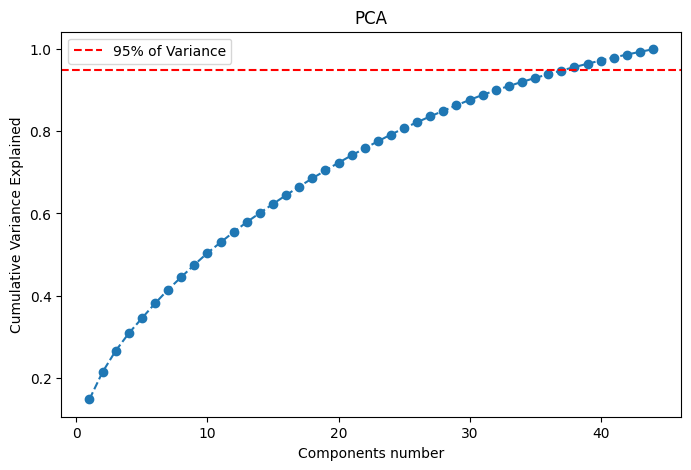

In [6]:
from core.analyse import calculate_PCA
'''
✔ remove noise
✔ reduce dimensionality
✔ mantain structure of the data

If PCA indicates many (20-30) components to explain 95% of the variance, this suggests that the data has high dimensionality, 
and perhaps reducing it to 2 components is too aggressive.

How to solve?
If we want to use DBSCAN, we need a number of components small enough to reduce noise, but large enough to capture
important information.

Options: 
-Reduce explainability 
-Try DBSCAN with multiple components

'''
# Normalize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(returns.T)  # Transpose --> this will put the prices on the top of columns,
X_scaled = calculate_PCA(X_scaled)

For 5 components, DBSCAN found 2 clusters
For 10 components, DBSCAN found 3 clusters
For 15 components, DBSCAN found 6 clusters
For 19 components, DBSCAN found 8 clusters
Possible Pairs:
['A', 'AAPL', 'ABBV', 'ABNB', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'ALLE', 'AMAT', 'AMCR', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANET', 'AON', 'AOS', 'APA', 'APD', 'APH', 'APO', 'APP', 'APTV', 'ARES', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRO', 'BSX', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CARR', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', 'CDW', 'CEG', 'CF', 'CFG', 'CHD', 'CHRW', 'CHTR', 'CI', 'CIEN', 'CINF', 'CL', 'CLX', 'CMCSA', 'CME', 'CMG', 'CMI', 'CMS', 'CNC', 'CNP', 'COF', 'COIN', 'COO', 'COP', 'COR', 'COST', 'CPAY', 'CPB', 'CPRT', 'CPT', 'CRH', 'CRL', 'CRM'

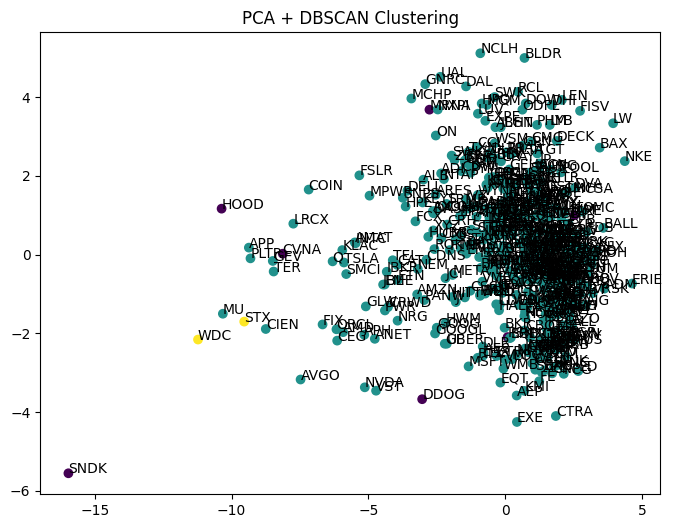

In [13]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


for n in [5, 10, 15, 19]:  # Test different number of components
    pca = PCA(n_components=n)
    X_pca = pca.fit_transform(X_scaled)
    
    dbscan = DBSCAN(eps=4, min_samples=2) #select the best EPS paramter --> bigger EPS, bigger clusters
    labels = dbscan.fit_predict(X_pca)
    
    num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"For {n} components, DBSCAN found {num_clusters} clusters")

#Clustering based on PCA components
pca = PCA(n_components=5) 
X_pca = pca.fit_transform(X_scaled)

dbscan = DBSCAN(eps=4, min_samples=2)  # choose the best parameters --> bigger EPS, bigger clusters
labels = dbscan.fit_predict(X_pca)

clusters = {}
tickers = returns.columns

for ticker, cluster in zip(tickers, labels):
    if cluster == -1:  # -1 noise points 
        continue
    if cluster not in clusters:
        clusters[cluster] = []
    clusters[cluster].append(ticker)

pairs = [group for group in clusters.values() if len(group) > 1]

print("Possible Pairs:")
for pair in pairs:
    print(pair)


plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)

for i, ticker in enumerate(returns.columns):
    plt.text(X_pca[i,0], X_pca[i,1], ticker)

plt.title("PCA + DBSCAN Clustering")
plt.show()

In [ ]:
clusters_list = [group for group in clusters.values() if len(group) > 1]

# all pairs combinations from the clusters
pairs = []

for cluster in clusters_list:
    
    for combo in combinations(cluster, 2):
        
        pairs.append(list(combo))

print("Candidate pairs:")
for p in pairs:
    print(p)